In [33]:
# Cell 1: imports and paths
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors as mcolors
import math

import duckdb
import re

from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from minisom import MiniSom

In [5]:
# Cell 2: load Radar-DINO features
FEATURE_PATH = Path("/home/dwefer/SULI-2026/feat2/features/feat.pth")

features = torch.load(FEATURE_PATH, map_location="cpu", weights_only=False)

if isinstance(features, torch.Tensor):
    X = features.detach().cpu().numpy()
else:
    X = np.asarray(features)

print(type(features))
print(X.shape)
print(X.dtype)

<class 'torch.Tensor'>
(5903, 384)
float32


In [6]:
# Cell 3: clean and standardize
X = np.asarray(X, dtype=np.float32)

good = np.isfinite(X).all(axis=1)
print(f"Good rows: {good.sum()} / {len(good)}")

X_good = X[good]

X_scaled = StandardScaler().fit_transform(X_good)
print(X_scaled.shape)

Good rows: 5903 / 5903
(5903, 384)


In [7]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",   # no PCA initialization
    max_iter=2000,
    random_state=0,
    verbose=1,
)

X_tsne = tsne.fit_transform(X_scaled)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5903 samples in 0.003s...
[t-SNE] Computed neighbors for 5903 samples in 0.371s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5903
[t-SNE] Computed conditional probabilities for sample 2000 / 5903
[t-SNE] Computed conditional probabilities for sample 3000 / 5903
[t-SNE] Computed conditional probabilities for sample 4000 / 5903
[t-SNE] Computed conditional probabilities for sample 5000 / 5903
[t-SNE] Computed conditional probabilities for sample 5903 / 5903
[t-SNE] Mean sigma: 0.544026
[t-SNE] KL divergence after 250 iterations with early exaggeration: 65.969803
[t-SNE] KL divergence after 2000 iterations: 0.688781


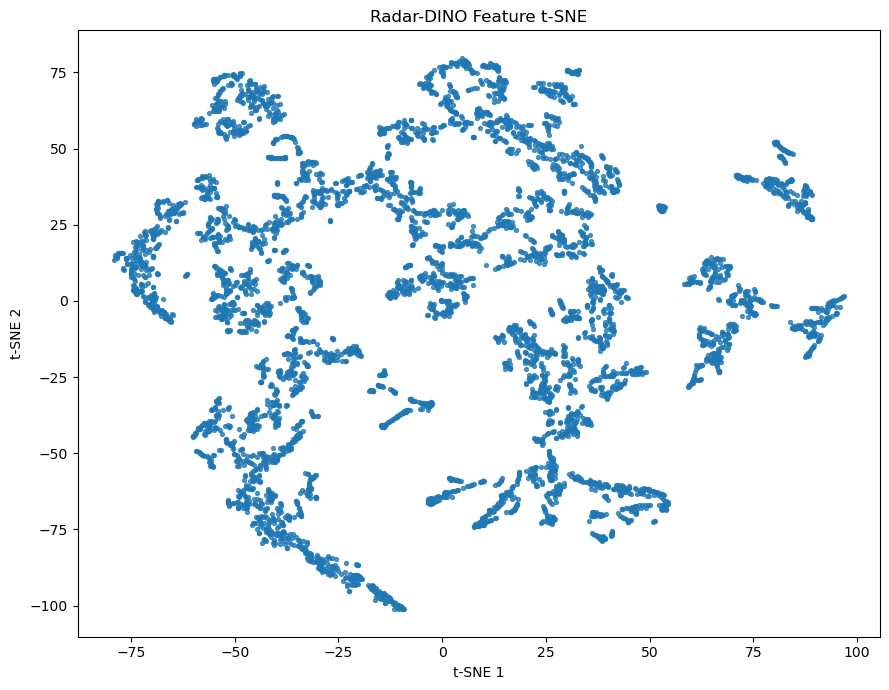

In [9]:
plt.figure(figsize=(9, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=8, alpha=0.75)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Radar-DINO Feature t-SNE")
plt.tight_layout()
plt.show()

In [10]:
# Cluster directly on the 2D t-SNE coordinates
dbscan = DBSCAN(
    eps=3.0,        # tune this
    min_samples=10, # tune this
)

dbscan_labels = dbscan.fit_predict(X_tsne)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = np.sum(dbscan_labels == -1)

print("clusters:", n_clusters)
print("noise points:", n_noise)
print("noise fraction:", n_noise / len(dbscan_labels))

clusters: 37
noise points: 80
noise fraction: 0.01355243096730476


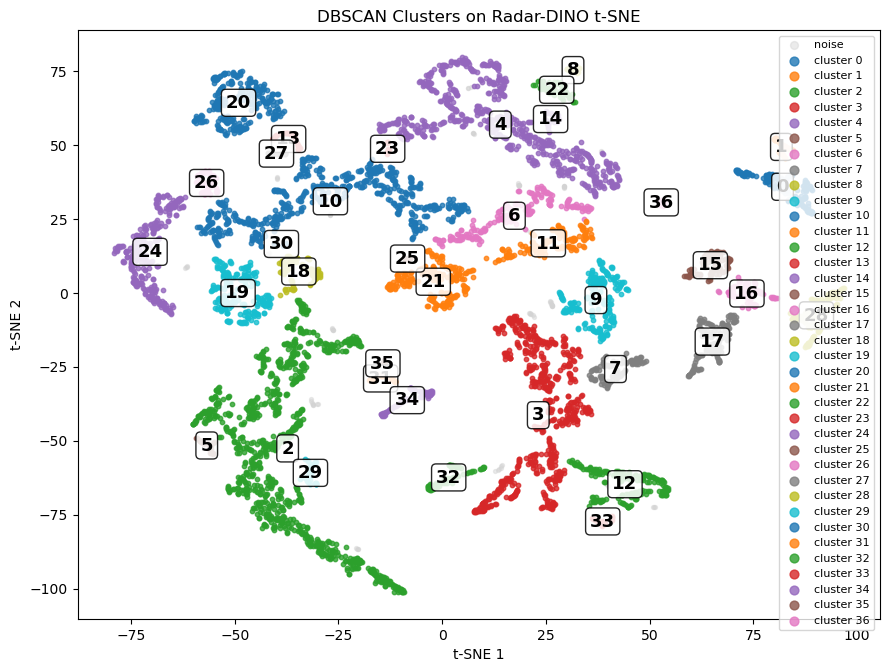

In [11]:
plt.figure(figsize=(9, 7))

unique_labels = sorted(set(dbscan_labels))

for label in unique_labels:
    mask = dbscan_labels == label

    if label == -1:
        plt.scatter(
            X_tsne[mask, 0],
            X_tsne[mask, 1],
            s=8,
            c="lightgray",
            alpha=0.45,
            label="noise",
        )
    else:
        plt.scatter(
            X_tsne[mask, 0],
            X_tsne[mask, 1],
            s=10,
            alpha=0.8,
            label=f"cluster {label}",
        )

        # Label the cluster at its t-SNE centroid
        cx = X_tsne[mask, 0].mean()
        cy = X_tsne[mask, 1].mean()

        plt.text(
            cx,
            cy,
            str(label),
            fontsize=13,
            fontweight="bold",
            ha="center",
            va="center",
            color="black",
            bbox=dict(
                facecolor="white",
                edgecolor="black",
                boxstyle="round,pad=0.25",
                alpha=0.85,
            ),
        )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("DBSCAN Clusters on Radar-DINO t-SNE")
plt.legend(markerscale=2, fontsize=8, loc="best")
plt.tight_layout()
plt.show()

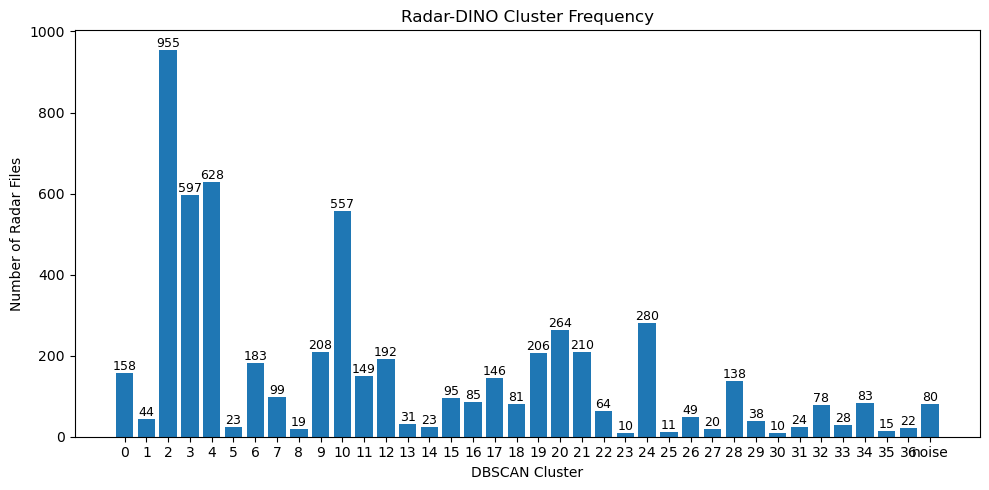

In [12]:
labels = np.asarray(dbscan_labels)

unique, counts = np.unique(labels, return_counts=True)

# Put DBSCAN noise cluster (-1) at the end
order = [i for i, u in enumerate(unique) if u != -1]
noise = [i for i, u in enumerate(unique) if u == -1]
order = order + noise

unique_ordered = unique[order]
counts_ordered = counts[order]

x_labels = ["noise" if u == -1 else f"{u}" for u in unique_ordered]

plt.figure(figsize=(10, 5))
bars = plt.bar(x_labels, counts_ordered)

plt.xlabel("DBSCAN Cluster")
plt.ylabel("Number of Radar Files")
plt.title("Radar-DINO Cluster Frequency")

for bar, count in zip(bars, counts_ordered):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

In [18]:
FEATURE_DIR = Path("/home/dwefer/SULI-2026/feat2/assoc_features")

file_paths = torch.load(
    FEATURE_DIR / "file_path.pth",
    map_location="cpu",
    weights_only=False,
)

old_prefix = Path("/eagle/SSL-SULI2026/dwefer/gridnc")

year_roots = {
    "2024": Path("/nfs/gce/globalscratch/dwefer/radar/adapt_ingest/KHTX/gridnc"),
    "2025": Path(
        "/home/dwefer/SULI-2026/data/"
        "adapt_alabama_2025_storm_events/adapt_ingest/KHTX/gridnc"
    ),
}

local_file_paths = []

for path in map(Path, file_paths):
    rel = path.relative_to(old_prefix)  # YYYYMMDD/filename.nc
    year = rel.parts[0][:4]

    if year not in year_roots:
        raise ValueError(f"No local path configured for year {year}: {path}")

    local_file_paths.append(year_roots[year] / rel)

print(local_file_paths[:3])
print(f"Existing: {sum(path.exists() for path in local_file_paths)}/{len(local_file_paths)}")

[PosixPath('/nfs/gce/globalscratch/dwefer/radar/adapt_ingest/KHTX/gridnc/20240109/KHTX20240109_034317_V06.nc'), PosixPath('/nfs/gce/globalscratch/dwefer/radar/adapt_ingest/KHTX/gridnc/20240109/KHTX20240109_034915_V06.nc'), PosixPath('/nfs/gce/globalscratch/dwefer/radar/adapt_ingest/KHTX/gridnc/20240109/KHTX20240109_035512_V06.nc')]


Existing: 5903/5903


In [19]:
rng = np.random.default_rng(0)

examples = {}

for label in sorted(set(dbscan_labels)):
    if label == -1:
        continue  # skip DBSCAN noise

    idxs = np.where(dbscan_labels == label)[0]
    chosen = rng.choice(idxs, size=min(5, len(idxs)), replace=False)
    examples[label] = chosen

    print()
    print(f"cluster {label}")
    for idx in chosen:
        print(idx, local_file_paths[idx])


cluster 0
2420 /home/dwefer/SULI-2026/data/adapt_alabama_2025_storm_events/adapt_ingest/KHTX/gridnc/20250213/KHTX20250213_000158_V06.nc
79 /nfs/gce/globalscratch/dwefer/radar/adapt_ingest/KHTX/gridnc/20240109/KHTX20240109_123033_V06.nc
42 /nfs/gce/globalscratch/dwefer/radar/adapt_ingest/KHTX/gridnc/20240109/KHTX20240109_083448_V06.nc
48 /nfs/gce/globalscratch/dwefer/radar/adapt_ingest/KHTX/gridnc/20240109/KHTX20240109_091051_V06.nc
2663 /home/dwefer/SULI-2026/data/adapt_alabama_2025_storm_events/adapt_ingest/KHTX/gridnc/20250315/KHTX20250315_231844_V06.nc

cluster 1
2357 /home/dwefer/SULI-2026/data/adapt_alabama_2025_storm_events/adapt_ingest/KHTX/gridnc/20250110/KHTX20250110_151827_V06.nc
2346 /home/dwefer/SULI-2026/data/adapt_alabama_2025_storm_events/adapt_ingest/KHTX/gridnc/20250110/KHTX20250110_141258_V06.nc
2351 /home/dwefer/SULI-2026/data/adapt_alabama_2025_storm_events/adapt_ingest/KHTX/gridnc/20250110/KHTX20250110_144257_V06.nc
2363 /home/dwefer/SULI-2026/data/adapt_alabama_2

In [20]:
def plot_radar_file(path, fields=("reflectivity", "specific_differential_phase", "differential_reflectivity", "cross_correlation_ratio"), z_level=2000.0):
    path = Path(path)

    with xr.open_dataset(path) as ds:
        n = len(fields)
        fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), constrained_layout=True)

        if n == 1:
            axes = [axes]

        for ax, field in zip(axes, fields):
            if field not in ds:
                ax.set_title(f"{field}\nmissing")
                ax.axis("off")
                continue

            da = ds[field]

            if "time" in da.dims:
                da = da.isel(time=0)

            if "z" in da.dims:
                da = da.sel(z=z_level, method="nearest")

            im = ax.imshow(da.values, origin="lower")
            ax.set_title(field)
            ax.axis("off")
            plt.colorbar(im, ax=ax, shrink=0.75)

        fig.suptitle(path.name)
        plt.show()

1598 /eagle/SSL-SULI2026/dwefer/gridnc/20240705/KHTX20240705_135613_V06.nc


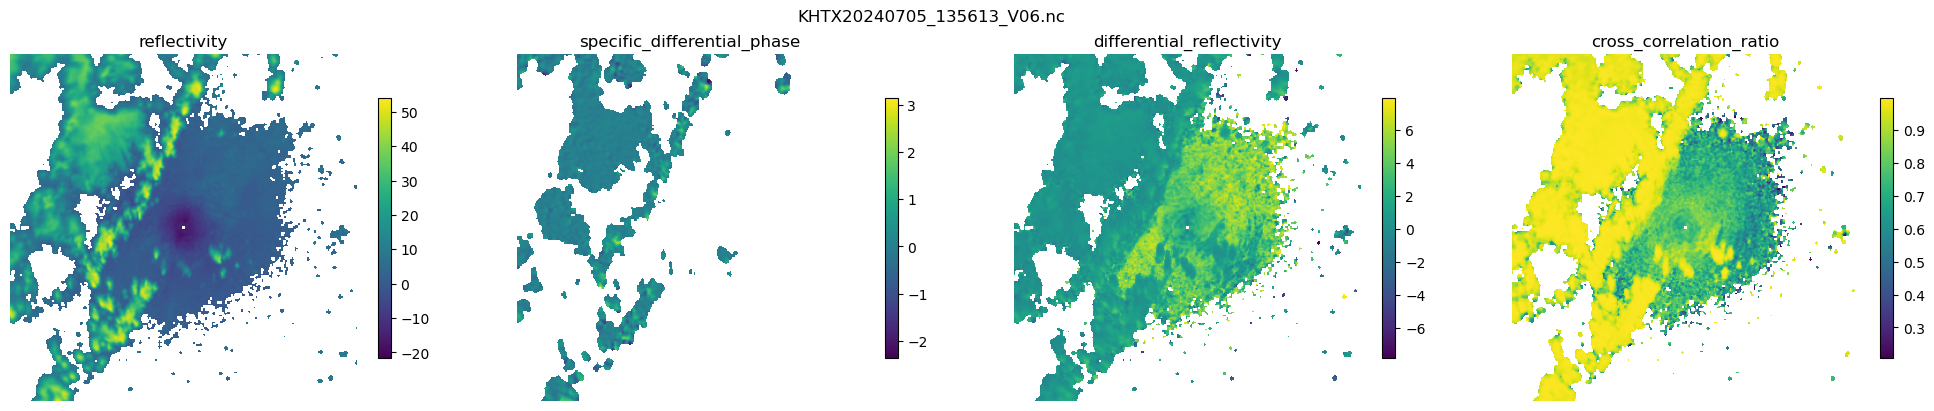

In [21]:
cluster_id = 25
idx = examples[cluster_id][1]

print(idx, file_paths[idx])
plot_radar_file(local_file_paths[idx])

1318 /eagle/SSL-SULI2026/dwefer/gridnc/20240527/KHTX20240527_090752_V06.nc


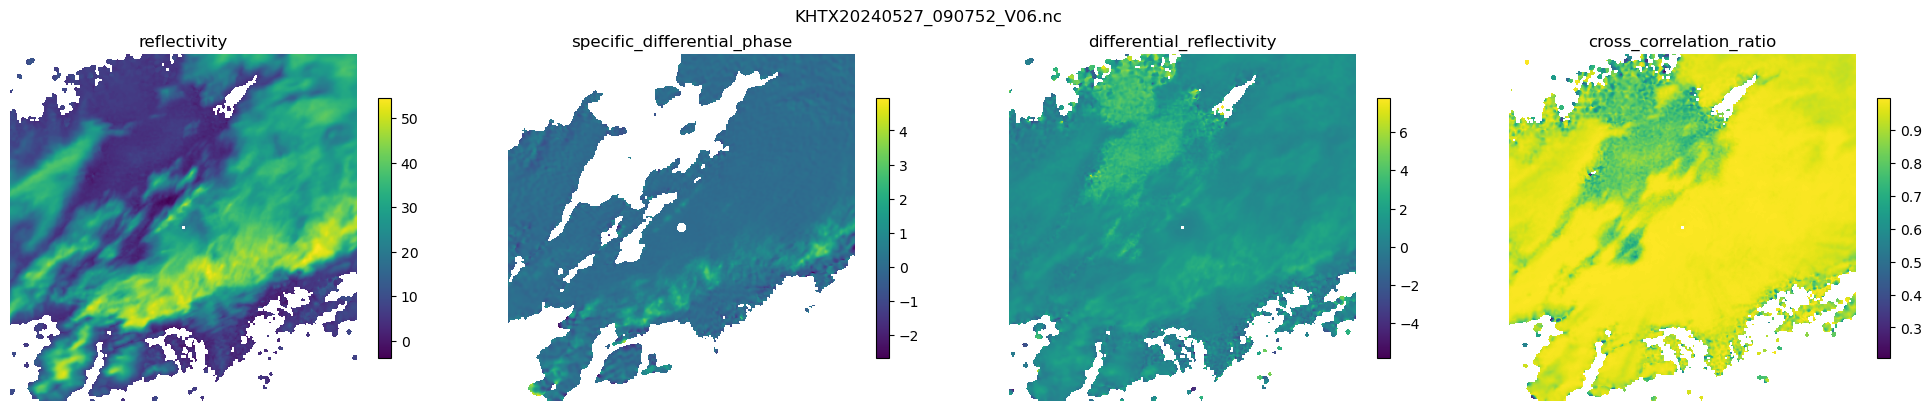

In [22]:
cluster_id = 12
idx = examples[cluster_id][1]

print(idx, file_paths[idx])
plot_radar_file(local_file_paths[idx])

In [23]:
# Build one row per t-SNE point from variables already in the notebook.
# X_tsne: shape (n_samples, 2)
# local_file_paths: list of matching NetCDF paths
def scan_time_from_path(path):
    match = re.search(r"[A-Z]{4}(\d{8})_(\d{6})", str(path))
    if match is None:
        return pd.NaT
    return pd.to_datetime("".join(match.groups()), format="%Y%m%d%H%M%S", utc=True)

paths_for_tsne = local_file_paths if "local_file_paths" in globals() else file_paths

tsne = pd.DataFrame({
    "tsne_x": X_tsne[:, 0],
    "tsne_y": X_tsne[:, 1],
    "file_path": [str(p) for p in paths_for_tsne],
})

tsne["scan_time"] = tsne["file_path"].map(scan_time_from_path)
tsne = tsne.dropna(subset=["scan_time"]).reset_index(drop=True)

con = duckdb.connect("/home/dwefer/SULI-2026/data/out/ALABAMA_windy-weather-episodes_2000-2026_v26-06.duckdb")

reports = con.execute("""
    SELECT
        episode,
        CAST(time AS TIMESTAMP) AS local_time,
        tzone,
        CAST(
            COALESCE(
                NULLIF(regexp_extract(tzone, '([+-][0-9]+)', 1), ''),
                '0'
            ) AS INTEGER
        ) AS offset_hours,
        tornado,
        thunderstorm_wind,
        high_wind,
        strong_wind,
        lightning,
        heavy_rain,
        flash_flood,
        flood,
        hail,
        winter_storm,
        blizzard
    FROM windy_weather_episodes
    WHERE time IS NOT NULL
""").fetchdf()

reports["report_time_utc"] = (
    pd.to_datetime(reports["local_time"])
    - pd.to_timedelta(reports["offset_hours"], unit="h")
).dt.tz_localize("UTC")

print(tsne.head())
print(reports[["episode", "report_time_utc"]].head())

      tsne_x     tsne_y                                          file_path  \
0  87.414040  28.701248  /nfs/gce/globalscratch/dwefer/radar/adapt_inge...   
1  87.330009  28.815212  /nfs/gce/globalscratch/dwefer/radar/adapt_inge...   
2  86.993500  29.274323  /nfs/gce/globalscratch/dwefer/radar/adapt_inge...   
3  86.935257  29.438803  /nfs/gce/globalscratch/dwefer/radar/adapt_inge...   
4  86.703415  29.804646  /nfs/gce/globalscratch/dwefer/radar/adapt_inge...   

                  scan_time  
0 2024-01-09 03:43:17+00:00  
1 2024-01-09 03:49:15+00:00  
2 2024-01-09 03:55:12+00:00  
3 2024-01-09 04:01:09+00:00  
4 2024-01-09 04:07:06+00:00  
   episode           report_time_utc
0  1090364 2000-01-03 16:45:00+00:00
1  1090365 2000-01-03 17:25:00+00:00
2  1090366 2000-01-03 17:34:00+00:00
3  1090367 2000-01-03 17:45:00+00:00
4  1090368 2000-01-03 18:12:30+00:00


In [24]:

# Build the t-SNE dataframe from variables already created in this notebook.
# NEXRAD file names like KHTX20250502_214504_V06.nc encode UTC scan time.
def scan_time_from_path(path):
    match = re.search(r"[A-Z]{4}(\d{8})_(\d{6})", str(path))
    if match is None:
        return pd.NaT
    return pd.to_datetime("".join(match.groups()), format="%Y%m%d%H%M%S", utc=True)

paths_for_tsne = local_file_paths if "local_file_paths" in globals() else file_paths

if len(X_tsne) != len(paths_for_tsne):
    raise ValueError(f"X_tsne has {len(X_tsne)} rows but paths has {len(paths_for_tsne)} rows")

tsne = pd.DataFrame({
    "tsne_x": X_tsne[:, 0],
    "tsne_y": X_tsne[:, 1],
    "file_path": [str(p) for p in paths_for_tsne],
})
tsne["scan_time"] = tsne["file_path"].map(scan_time_from_path)
tsne = tsne.dropna(subset=["scan_time"]).reset_index(drop=True)

con = duckdb.connect("../data/out/ALABAMA_windy-weather-episodes_2000-2026_v26-06.duckdb")

reports = con.execute("""
    SELECT
        episode,
        CAST(time AS TIMESTAMP) AS local_time,
        tzone,
        CAST(
            COALESCE(
                NULLIF(regexp_extract(tzone, '([+-][0-9]+)', 1), ''),
                '0'
            ) AS INTEGER
        ) AS offset_hours,
        tornado,
        thunderstorm_wind,
        high_wind,
        strong_wind,
        lightning,
        heavy_rain,
        flash_flood,
        flood,
        hail,
        winter_storm,
        blizzard
    FROM windy_weather_episodes
    WHERE time IS NOT NULL
""").fetchdf()

reports["report_time_utc"] = (
    pd.to_datetime(reports["local_time"])
    - pd.to_timedelta(reports["offset_hours"], unit="h")
).dt.tz_localize("UTC")

print(f"t-SNE rows: {len(tsne)}")
print(tsne[["scan_time", "file_path"]].head())

t-SNE rows: 5903
                  scan_time                                          file_path
0 2024-01-09 03:43:17+00:00  /nfs/gce/globalscratch/dwefer/radar/adapt_inge...
1 2024-01-09 03:49:15+00:00  /nfs/gce/globalscratch/dwefer/radar/adapt_inge...
2 2024-01-09 03:55:12+00:00  /nfs/gce/globalscratch/dwefer/radar/adapt_inge...
3 2024-01-09 04:01:09+00:00  /nfs/gce/globalscratch/dwefer/radar/adapt_inge...
4 2024-01-09 04:07:06+00:00  /nfs/gce/globalscratch/dwefer/radar/adapt_inge...


In [25]:
def report_label(row):
    for label in [
        "tornado",
        "thunderstorm_wind",
        "high_wind",
        "strong_wind",
        "lightning",
        "heavy_rain",
        "flash_flood",
        "flood",
        "hail",
        "winter_storm",
        "blizzard",
    ]:
        if bool(row.get(label)):
            return label
    return "other"

reports["storm_label"] = reports.apply(report_label, axis=1)

tsne_sorted = tsne.sort_values("scan_time")
reports_sorted = reports.sort_values("report_time_utc")

matched = pd.merge_asof(
    tsne_sorted,
    reports_sorted[["report_time_utc", "episode", "storm_label"]],
    left_on="scan_time",
    right_on="report_time_utc",
    direction="nearest",
    tolerance=pd.Timedelta("90min"),
)

matched["storm_label"] = matched["storm_label"].fillna("no_nearby_report")
matched["time_delta_minutes"] = (
    matched["scan_time"] - matched["report_time_utc"]
).abs().dt.total_seconds() / 60

matched.head()

,tsne_x,tsne_y,file_path,scan_time,report_time_utc,episode,storm_label,time_delta_minutes
0,87.414040,28.701248,/nfs/gce/globalscratch/dwefer/radar/adapt_inge...,2024-01-09 03:43:17+00:00,2024-01-09 05:10:00+00:00,186867,strong_wind,86.716667
1,87.330009,28.815212,/nfs/gce/globalscratch/dwefer/radar/adapt_inge...,2024-01-09 03:49:15+00:00,2024-01-09 05:10:00+00:00,186867,strong_wind,80.750000
2,86.993500,29.274323,/nfs/gce/globalscratch/dwefer/radar/adapt_inge...,2024-01-09 03:55:12+00:00,2024-01-09 05:10:00+00:00,186867,strong_wind,74.800000
3,86.935257,29.438803,/nfs/gce/globalscratch/dwefer/radar/adapt_inge...,2024-01-09 04:01:09+00:00,2024-01-09 05:10:00+00:00,186867,strong_wind,68.850000
4,86.703415,29.804646,/nfs/gce/globalscratch/dwefer/radar/adapt_inge...,2024-01-09 04:07:06+00:00,2024-01-09 05:10:00+00:00,186867,strong_wind,62.900000


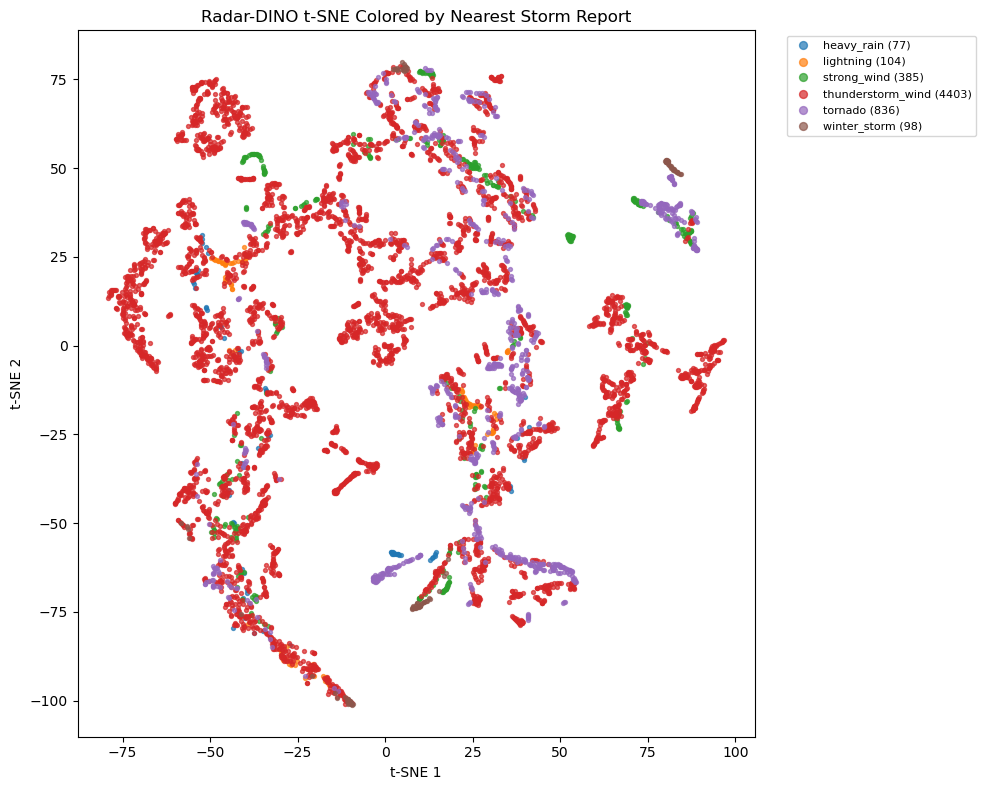

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))

for label, group in matched.groupby("storm_label"):
    ax.scatter(
        group["tsne_x"],
        group["tsne_y"],
        s=8,
        alpha=0.7,
        label=f"{label} ({len(group)})",
    )

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Radar-DINO t-SNE Colored by Nearest Storm Report")
ax.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [27]:


# Attach DBSCAN cluster labels to the nearest-report matched dataframe.
# matched was sorted by scan_time during merge_asof, so preserve original sample index first.
tsne_with_index = tsne.copy()
tsne_with_index["sample_index"] = np.arange(len(tsne_with_index))
tsne_with_index["dbscan_cluster"] = dbscan_labels[:len(tsne_with_index)]

matched_with_cluster = matched.merge(
    tsne_with_index[["file_path", "sample_index", "dbscan_cluster"]],
    on="file_path",
    how="left",
)

# Optional: remove DBSCAN noise points.
plot_df = matched_with_cluster[matched_with_cluster["dbscan_cluster"] != -1].copy()

breakdown = (
    plot_df
    .groupby(["dbscan_cluster", "storm_label"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

breakdown

storm_label,heavy_rain,lightning,strong_wind,thunderstorm_wind,tornado,winter_storm
dbscan_cluster,,,,,,
0,0,0,50,13,95,0
1,0,0,0,0,14,30
2,23,26,62,758,69,17
3,3,37,69,346,111,31
4,0,0,87,390,135,16
5,0,0,0,19,0,4
6,0,0,0,154,29,0
7,5,0,0,82,12,0
8,0,0,0,19,0,0


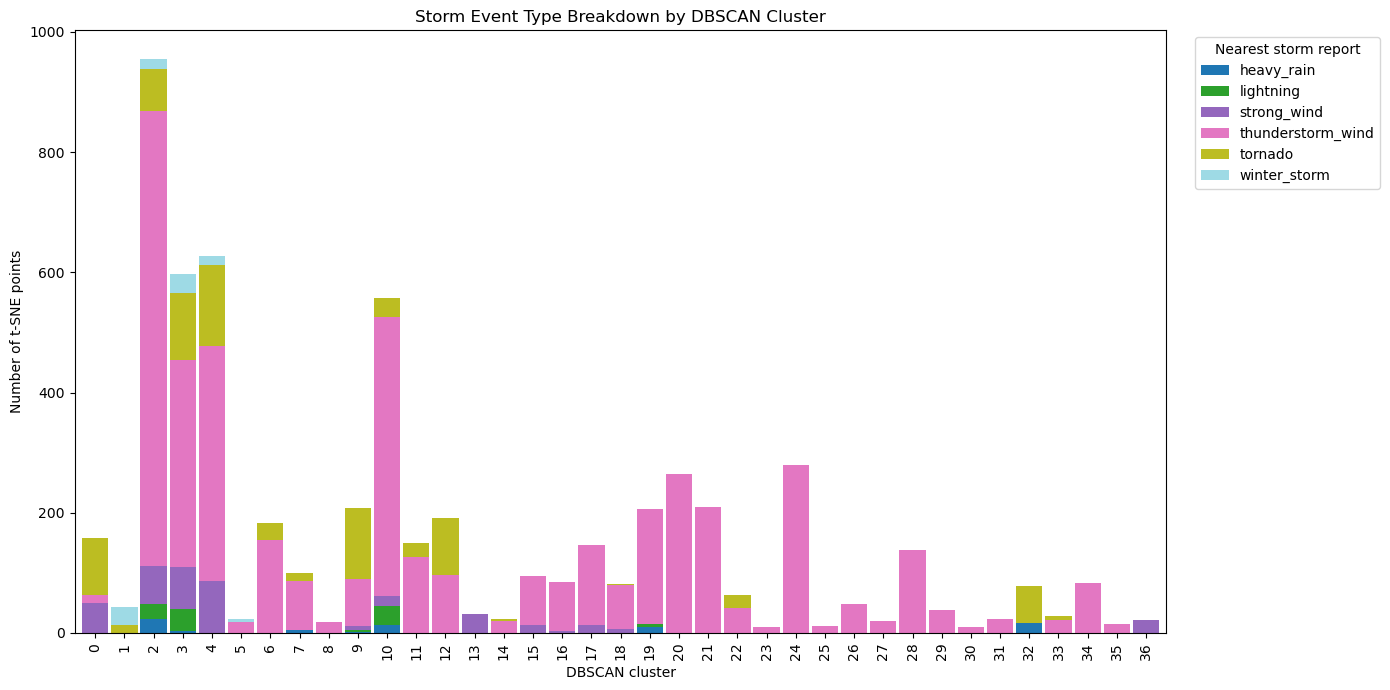

In [28]:
ax = breakdown.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    width=0.9,
    colormap="tab20",
)

ax.set_xlabel("DBSCAN cluster")
ax.set_ylabel("Number of t-SNE points")
ax.set_title("Storm Event Type Breakdown by DBSCAN Cluster")
ax.legend(title="Nearest storm report", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

2351 /eagle/SSL-SULI2026/dwefer/gridnc/20250110/KHTX20250110_144257_V06.nc


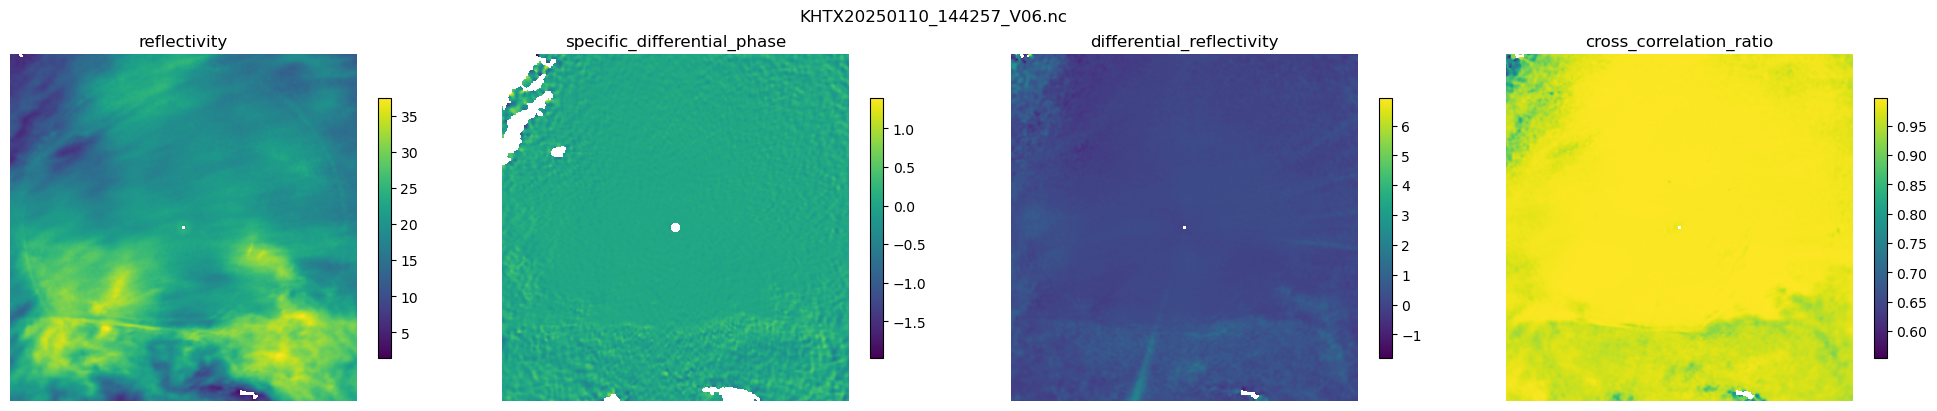

In [30]:
cluster_id = 1

idx = examples[cluster_id][2]

print(idx, file_paths[idx])
plot_radar_file(local_file_paths[idx])

In [31]:


def radarscope_br():
    colors = [("#734DAC", -32), ("#734FA5", -31), ("#74529E", -30), ("#745598", -29), ("#755891", -28), ("#765B8A", -27),
              ("#765E84", -26), ("#77607D", -25), ("#786376", -24), ("#786670", -23), ("#796969", -22), ("#7A6C62", -21),
              ("#7A6F5C", -20), ("#7B7155", -19), ("#7C744E", -18), ("#7C7748", -17), ("#7F7B48", -16), ("#837F4F", -15),
              ("#878455", -14), ("#8B895C", -13), ("#908D63", -12), ("#94926A", -11), ("#989771", -10), ("#9C9B77", -9),
              ("#A1A07E", -8), ("#A5A585", -7), ("#A9A98C", -6), ("#ADAE93", -5), ("#B2B39A", -4), ("#A8AB98", -3),
              ("#9EA396", -2), ("#959B94", -1), ("#8B9392", 0), ("#828C90", 1), ("#78848E", 2), ("#6F7C8D", 3),
              ("#65748B", 4), ("#5C6D89", 5), ("#526587", 6), ("#495D85", 7), ("#3F5583", 8), ("#364E82", 9), 
              ("#395586", 10), ("#3D5D8A", 11), ("#41658F", 12), ("#456D93", 13), ("#497598", 14), ("#4C7D9C", 15), 
              ("#5085A0", 16), ("#548DA5", 17), ("#5895A9", 18), ("#5C9DAE", 19), ("#3CAD6E", 20), ("#2AAF48", 21), 
              ("#25A33E", 22), ("#1F9633", 23), ("#1A8928", 24), ("#157D1E", 25), ("#107013", 26), ("#0B6409", 27), 
              ("#3B8207", 28), ("#6BA105", 29), ("#9BBF03", 30), ("#CBDE01", 31), ("#FCFD00", 32), ("#F4F300", 33), 
              ("#EDE900", 34), ("#E6DF00", 35), ("#DED500", 36), ("#D7CB00", 37), ("#D0C100", 38), ("#C8B700", 39), 
              ("#FA9400", 40), ("#F28D01", 41), ("#EA8702", 42), ("#E38103", 43), ("#DB7B05", 44), ("#D47406", 45), 
              ("#CC6E07", 46), ("#C46808", 47), ("#BD620A", 48), ("#B55C0B", 49), ("#F9230B", 50), ("#EC230D", 51), 
              ("#DF240F", 52), ("#D32411", 53), ("#C62513", 54), ("#BA2516", 55), ("#AD2618", 56), ("#A1261A", 57), 
              ("#94271C", 58), ("#88271E", 59), ("#CA99B4", 60), ("#C98BAD", 61), ("#C87EA6", 62), ("#C7719F", 63), 
              ("#C66498", 64), ("#C55791", 65), ("#C44A8A", 66), ("#C43C83", 67), ("#C32F7C", 68), ("#C22275", 69), 
              ("#9A24E0", 70), ("#9021D7", 71), ("#861FCE", 72), ("#7C1DC5", 73), ("#731BBC", 74), ("#6918B3", 75), 
              ("#5F16AA", 76), ("#5614A2", 77), ("#4C1299", 78), ("#421090", 79), ("#84FDFF", 80), ("#7DEEF3", 81), 
              ("#76E0E7", 82), ("#6FD2DB", 83), ("#69C4CF", 84), ("#62B5C4", 85), ("#5BA7B8", 86), ("#5499AC", 87), 
              ("#4E8BA0", 88), ("#477D94", 89), ("#A16549", 90), ("#965038", 91), ("#8C3C28", 92), ("#822818", 93), ("#781408", 94)]

    hex_colors = [color for color, _ in colors]
    Radarscope_BR = ListedColormap(hex_colors, "Radarscope_BR")
    matplotlib.colormaps.register(cmap = Radarscope_BR)

radarscope_br()

/tmp/ipykernel_2872095/877450590.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.95])


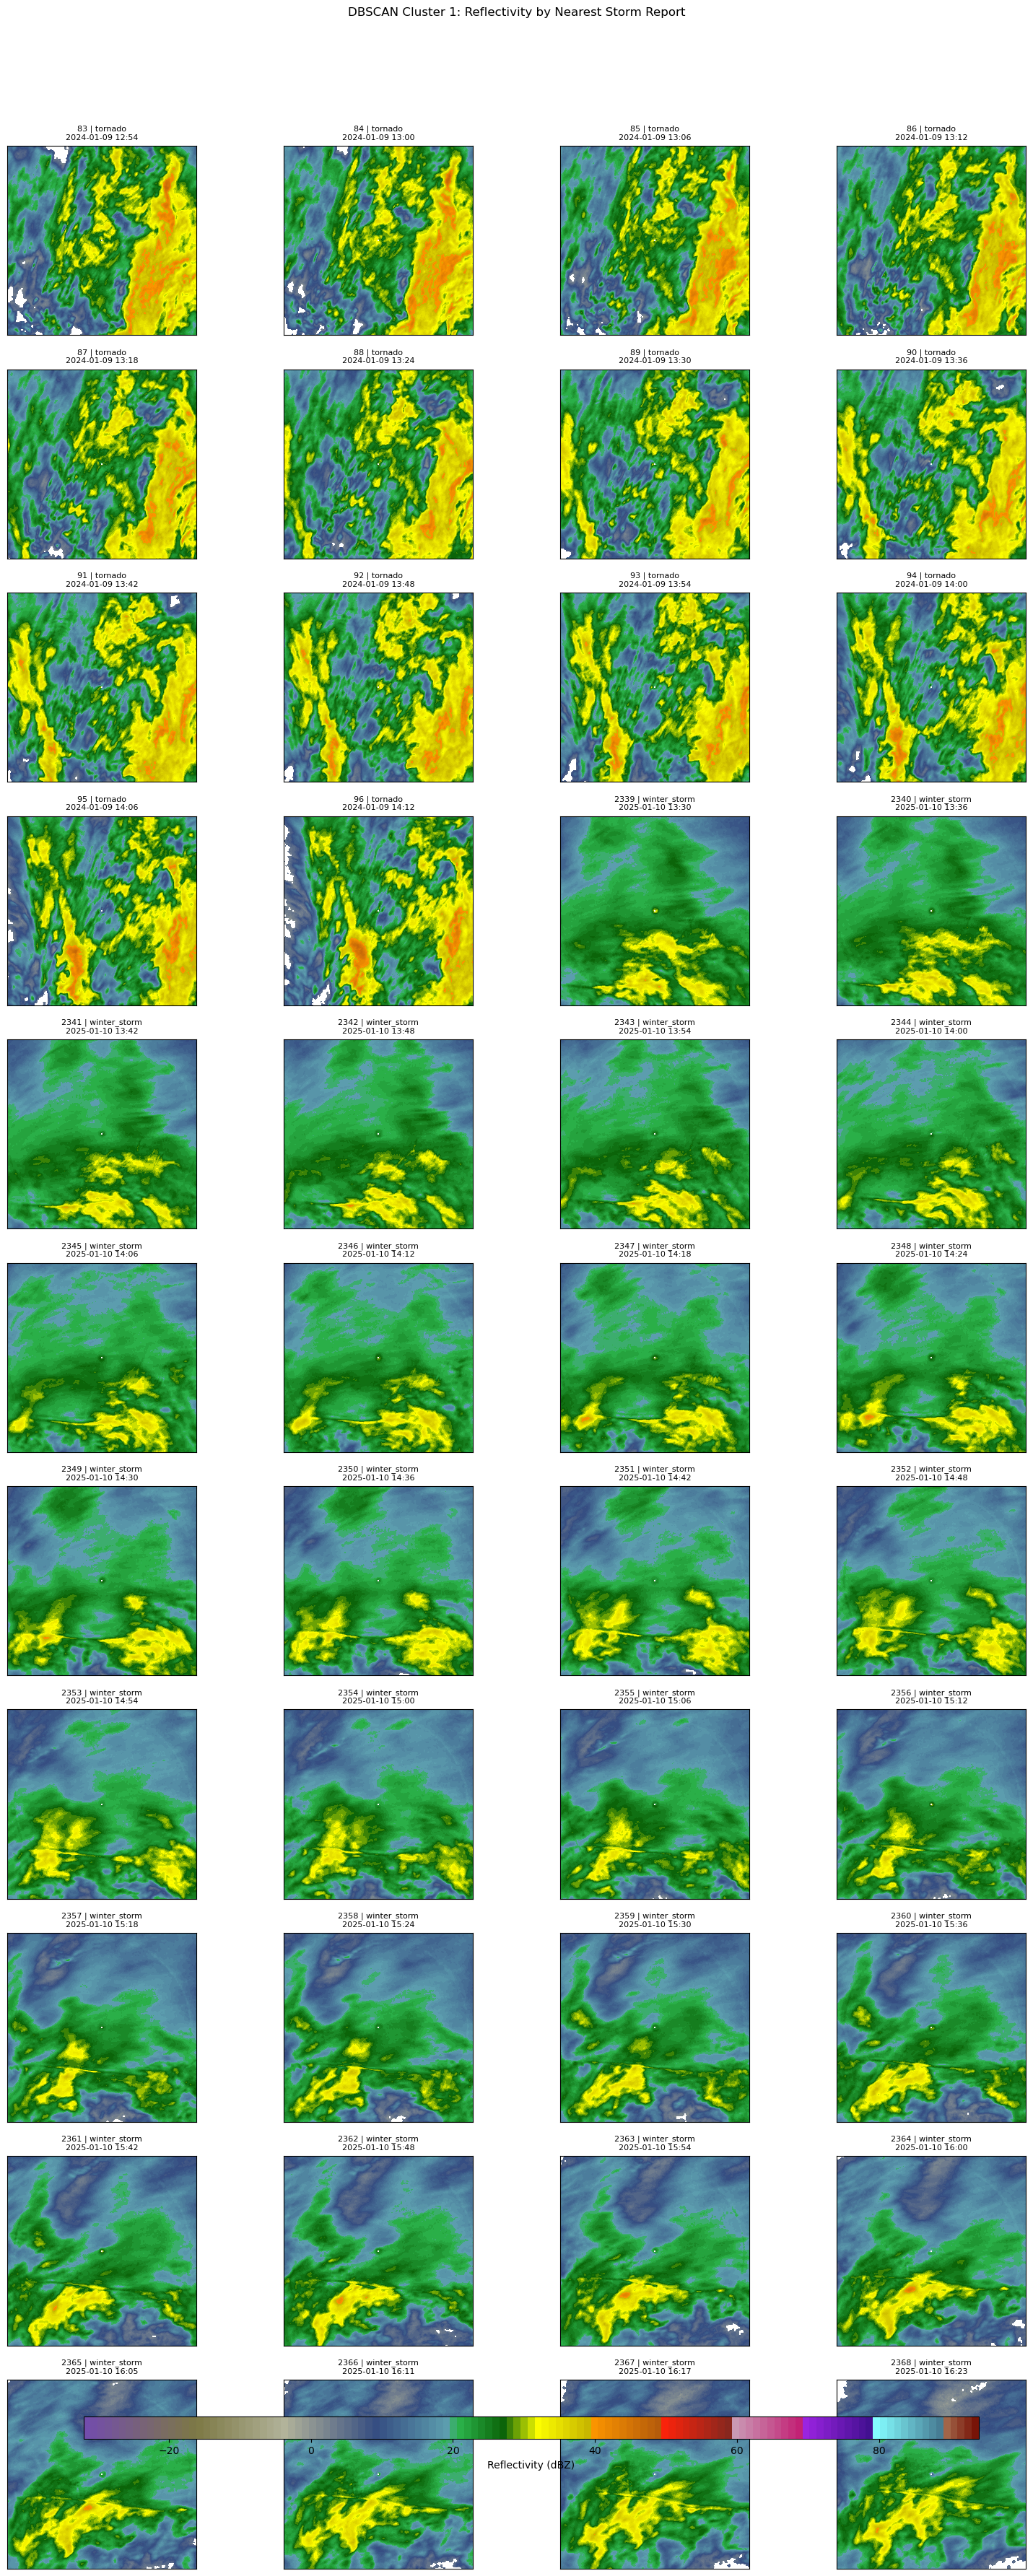

In [32]:


cluster_id = 1
field = "reflectivity"

cluster_samples = (
    matched_with_cluster[matched_with_cluster["dbscan_cluster"] == cluster_id]
    .sort_values(["storm_label", "scan_time"])
    .reset_index(drop=True)
)

# Optional for large clusters
# cluster_samples = (
#     cluster_samples
#     .sample(24, random_state=0)
#     .sort_values(["storm_label", "scan_time"])
#     .reset_index(drop=True)
# )

n = len(cluster_samples)
cols = 4
rows = math.ceil(n / cols)

cmap = matplotlib.colormaps["Radarscope_BR"]
norm = mcolors.Normalize(vmin=-32, vmax=94)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4 * cols, 3.6 * rows),
    squeeze=False,
)

im = None

for ax, (_, row) in zip(axes.ravel(), cluster_samples.iterrows()):
    path = row["file_path"]

    with xr.open_dataset(path) as ds:
        if field not in ds:
            ax.set_title(f"{int(row['sample_index'])}: missing {field}", fontsize=8)
            ax.axis("off")
            continue

        da = ds[field]

        if "time" in da.dims:
            da = da.isel(time=0)

        if "z" in da.dims:
            z_idx = int(np.argmin(np.abs(ds["z"].values - 2000.0)))
            da = da.isel(z=z_idx)

        arr = da.values.astype(float)

    im = ax.imshow(
        arr,
        origin="lower",
        cmap=cmap,
        norm=norm,
    )

    ax.set_title(
        f"{int(row['sample_index'])} | {row['storm_label']}\n"
        f"{pd.to_datetime(row['scan_time']).strftime('%Y-%m-%d %H:%M')}",
        fontsize=8,
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.ravel()[n:]:
    ax.axis("off")

if im is not None:
    cbar = fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.035,
        pad=0.04,
        aspect=40,
    )
    cbar.set_label("Reflectivity (dBZ)")

fig.suptitle(
    f"DBSCAN Cluster {cluster_id}: Reflectivity by Nearest Storm Report",
    y=0.98,
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

In [34]:
if hasattr(X, "detach"):
    X = X.detach().cpu().numpy()

X = np.asarray(X, dtype=np.float32)

print("Feature shape:", X.shape)

Feature shape: (5903, 384)


In [50]:
# X shape: (n_samples, 384)
X = np.asarray(X, dtype=np.float32)

# DINO features should already be L2-normalized.
print("Input shape:", X.shape)

Input shape: (5903, 384)


2D explained variance: [0.32294595 0.27575517]
Total: 0.5987011


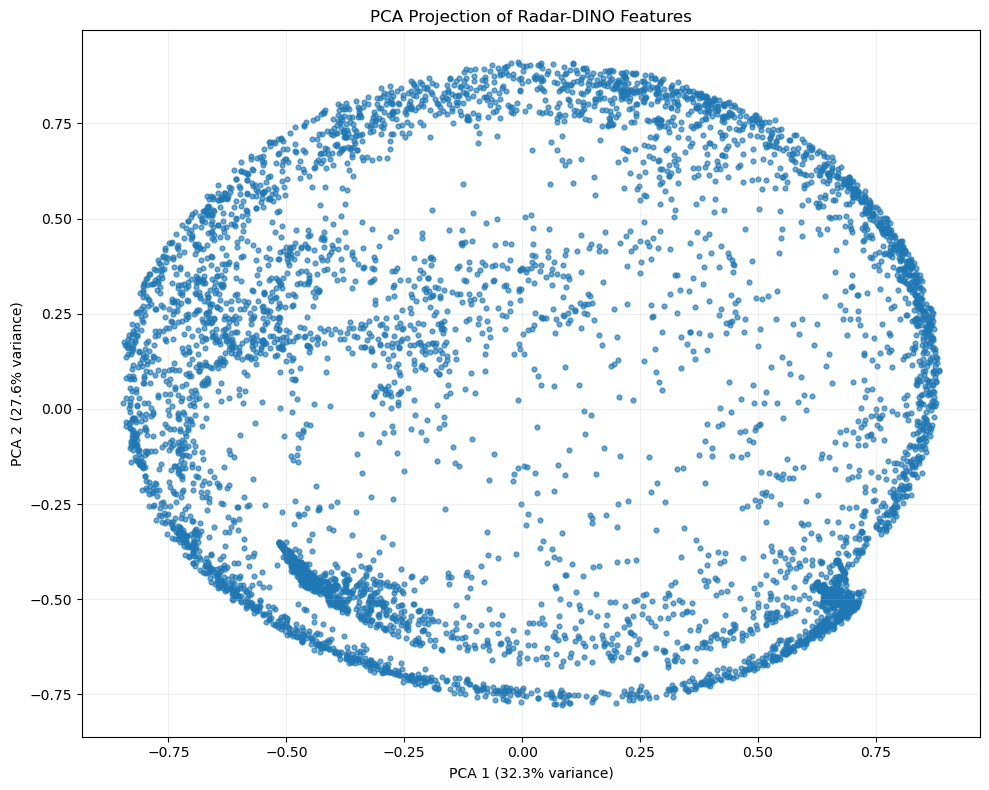

In [51]:
pca_plot = PCA(n_components=2, random_state=0)
X_pca_2d = pca_plot.fit_transform(X)

print("2D explained variance:", pca_plot.explained_variance_ratio_)
print("Total:", pca_plot.explained_variance_ratio_.sum())

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    s=12,
    alpha=0.65,
)

ax.set_xlabel(
    f"PCA 1 ({pca_plot.explained_variance_ratio_[0] * 100:.1f}% variance)"
)
ax.set_ylabel(
    f"PCA 2 ({pca_plot.explained_variance_ratio_[1] * 100:.1f}% variance)"
)
ax.set_title("PCA Projection of Radar-DINO Features")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [62]:
pca_som = PCA(n_components=383, random_state=0)
X_pca_som = pca_som.fit_transform(X)

print("SOM input shape:", X_pca_som.shape)
print(
    "Retained variance:",
    pca_som.explained_variance_ratio_.sum(),
)

SOM input shape: (5903, 383)
Retained variance: 1.0


In [67]:
som_rows = 3
som_cols = 4

som = MiniSom(
    x=som_rows,
    y=som_cols,
    input_len=X_pca_som.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    neighborhood_function="gaussian",
    activation_distance="euclidean",
    random_seed=0,
)

som.pca_weights_init(X_pca_som)
som.train_random(
    X_pca_som,
    num_iteration=20_000,
    verbose=True,
)

som_winners = np.array([
    som.winner(sample)
    for sample in X_pca_som
])

som_labels = (
    som_winners[:, 0] * som_cols
    + som_winners[:, 1]
)

print("SOM clusters used:", len(np.unique(som_labels)))

 [ 20000 / 20000 ] 100% - 0:00:00 left 
 quantization error: 0.34009695339576224
SOM clusters used: 12


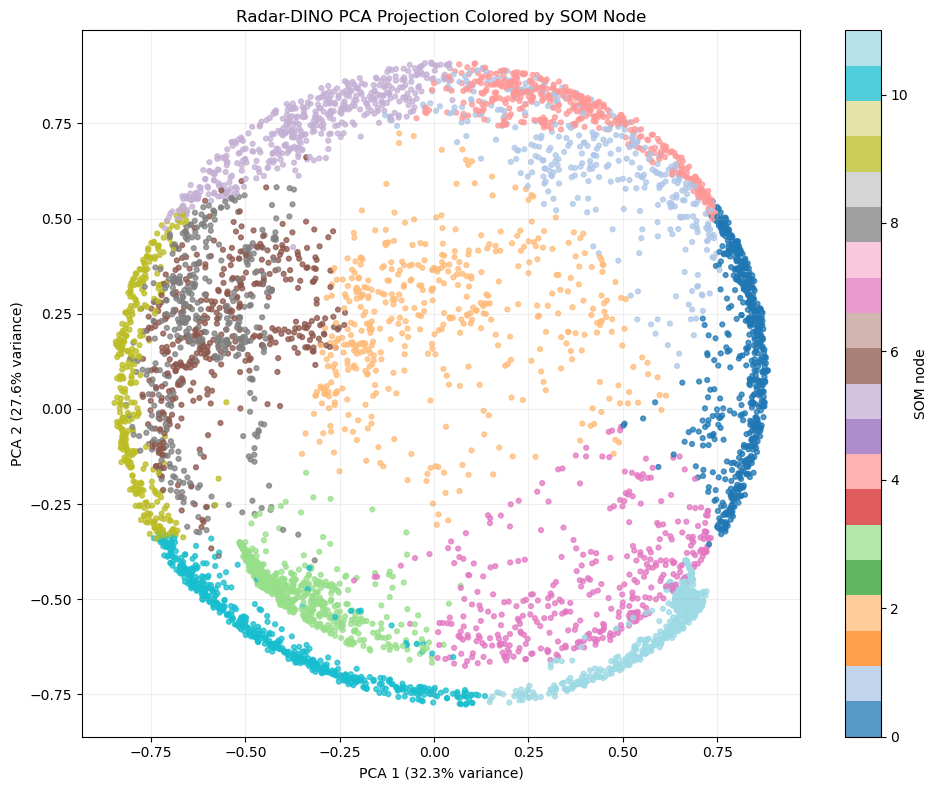

In [68]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=som_labels,
    cmap="tab20",
    s=12,
    alpha=0.75,
)

ax.set_xlabel(
    f"PCA 1 ({pca_plot.explained_variance_ratio_[0] * 100:.1f}% variance)"
)
ax.set_ylabel(
    f"PCA 2 ({pca_plot.explained_variance_ratio_[1] * 100:.1f}% variance)"
)
ax.set_title("Radar-DINO PCA Projection Colored by SOM Node")
ax.grid(alpha=0.2)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("SOM node")

plt.tight_layout()
plt.show()

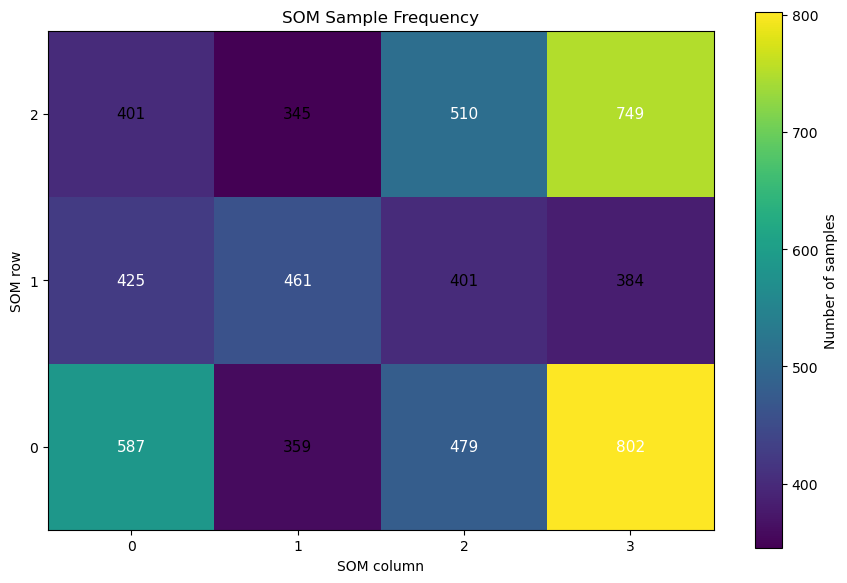

In [69]:
occupancy = np.zeros((som_rows, som_cols), dtype=int)

for row, col in som_winners:
    occupancy[row, col] += 1

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    occupancy,
    origin="lower",
    cmap="viridis",
)

threshold = occupancy.max() / 2

for row in range(som_rows):
    for col in range(som_cols):
        ax.text(
            col,
            row,
            str(occupancy[row, col]),
            ha="center",
            va="center",
            color="white" if occupancy[row, col] > threshold else "black",
            fontsize=11,
        )

ax.set_xticks(range(som_cols))
ax.set_yticks(range(som_rows))
ax.set_xlabel("SOM column")
ax.set_ylabel("SOM row")
ax.set_title("SOM Sample Frequency")

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Number of samples")

plt.tight_layout()
plt.show()

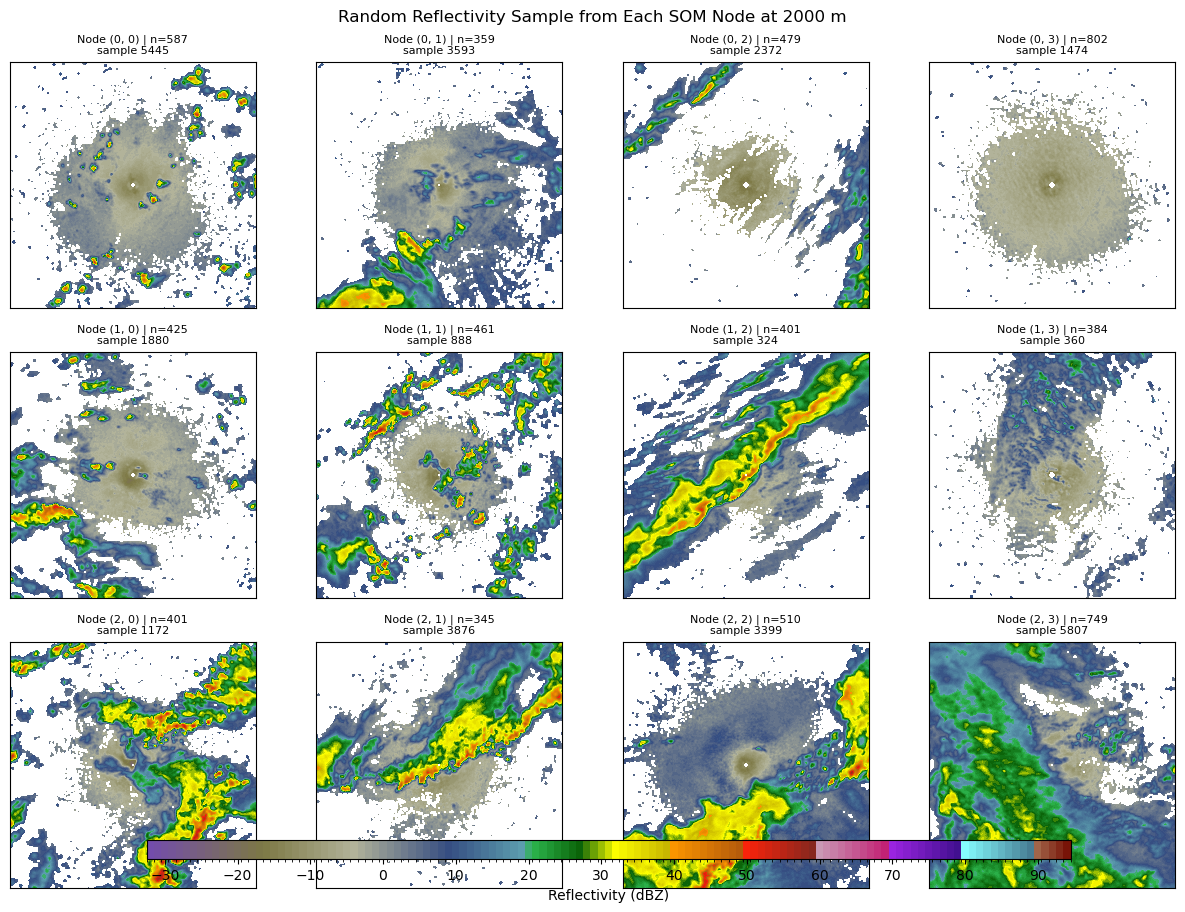

In [70]:
rng = np.random.default_rng(0)
z_level = 2000.0

cmap = matplotlib.colormaps["Radarscope_BR"]

# One color for every integer dBZ value from -32 through 94.
boundaries = np.arange(-32.5, 95.5, 1.0)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

fig, axes = plt.subplots(
    som_rows,
    som_cols,
    figsize=(3.2 * som_cols, 3.2 * som_rows),
    squeeze=False,
)

im = None

for row in range(som_rows):
    for col in range(som_cols):
        ax = axes[row, col]

        indices = np.flatnonzero(
            (som_winners[:, 0] == row)
            & (som_winners[:, 1] == col)
        )

        if len(indices) == 0:
            ax.set_facecolor("lightgray")
            ax.text(
                0.5,
                0.5,
                "Empty",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_title(f"Node ({row}, {col})")
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        sample_index = int(rng.choice(indices))
        path = local_file_paths[sample_index]

        try:
            with xr.open_dataset(path) as ds:
                reflectivity = ds["reflectivity"]

                if "time" in reflectivity.dims:
                    reflectivity = reflectivity.isel(time=0)

                if "z" in reflectivity.dims:
                    reflectivity = reflectivity.sel(
                        z=z_level,
                        method="nearest",
                    )

                values = reflectivity.values.astype(float)

            im = ax.imshow(
                values,
                origin="lower",
                cmap=cmap,
                norm=norm,
            )

            ax.set_title(
                f"Node ({row}, {col}) | n={len(indices)}\n"
                f"sample {sample_index}",
                fontsize=8,
            )

        except Exception as exc:
            ax.text(
                0.5,
                0.5,
                f"Could not read\n{type(exc).__name__}",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=8,
            )
            ax.set_title(f"Node ({row}, {col})")

        ax.set_xticks([])
        ax.set_yticks([])

if im is not None:
    cbar = fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.025,
        pad=0.035,
        aspect=50,
    )
    cbar.set_label("Reflectivity (dBZ)")
    cbar.set_ticks(np.arange(-30, 91, 10))

fig.suptitle(
    f"Random Reflectivity Sample from Each SOM Node at {z_level:.0f} m",
    y=0.995,
)

plt.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.94,
    bottom=0.08,
    wspace=0.08,
    hspace=0.18,
)

plt.show()